In [1]:
import numpy as np
import scipy.stats
import astropy
import pylab as plt
import os

In [ ]:
from urllib.request import urlretrieve
filename = './dr7qso.dat'
if not os.path.exists(filename):
   urlretrieve("https://das.sdss.org/va/qsocat/dr7qso.dat", filename)

data = np.loadtxt(filename,skiprows=80, usecols=3)
os.remove(filename)

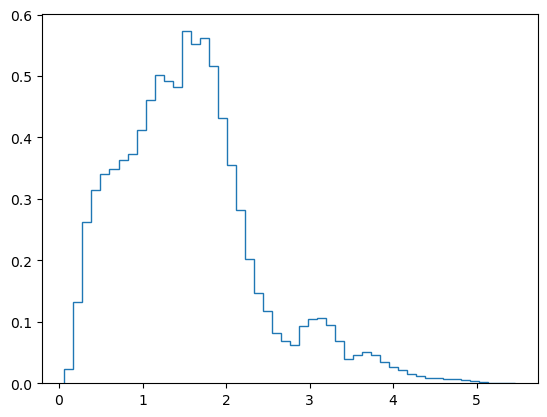

In [3]:
plt.hist(data,bins=50,histtype='step',density=True,label='original data');

### Cloning by rejection sampling

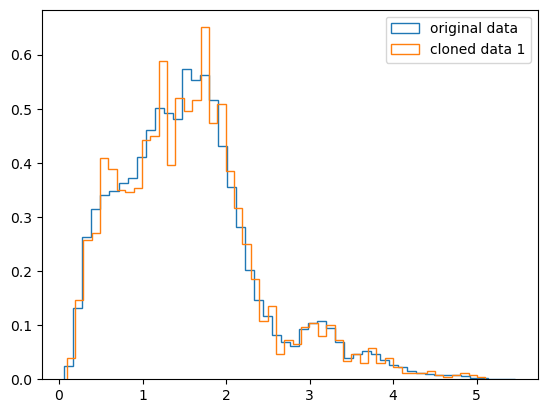

In [4]:
plt.hist(data,bins=50,histtype='step',density=True,label='original data');

maxh = 1

# Make a scipy.stats random variable object from a histogram
counts, bins = np.histogram(data, bins=50, density=True)
disth = scipy.stats.rv_histogram((counts,bins))

N = 100000 # trials
q = np.random.uniform(-10, 30, N) # proposed points
u = np.random.uniform(0, maxh, N) # uniform draws

mask = u<=disth.pdf(q) # assess whether u <= q(x_i)

monte_carlo = q[mask] # reject all points that don't pass, using masking

plt.hist(monte_carlo, bins=50, density=True,histtype='step',label='cloned data 1');

plt.legend();

### Cloning by inverse transform

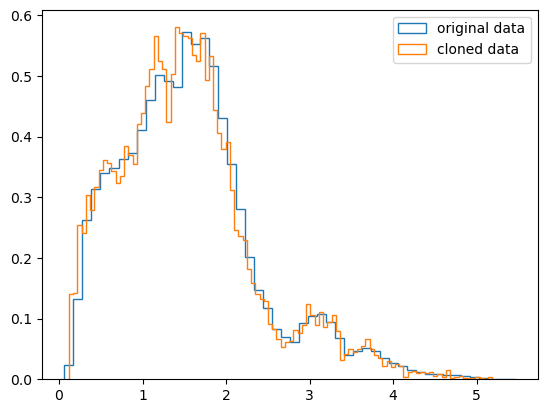

In [5]:
plt.hist(data,bins=50,histtype='step',density=True,label='original data');

# make a simple histogram object
counts, bins = np.histogram(data, bins=50, density=True)
bin_mids = (bins[1:] + bins[:-1]) / 2 # mid location of bins
 
simple_cdf = np.cumsum(counts) / np.sum(counts) # very simply cumulative sum

# set up an interpolation of the inverse cumulative distribution
tck = scipy.interpolate.interp1d(simple_cdf, bin_mids)

# sample uniformly along the cumulative distribution, and interpolate
# little hack to make sure no points are generated outside interpolation range.
# not ideal
u = np.random.uniform(min(simple_cdf),max(simple_cdf), 10000) 
x_sample = tck(u)

plt.hist(x_sample, bins=100, density=True, histtype='step',label='cloned data');

plt.legend();

### Cloning with scipy.stats

This is actually already implemented in scipy.stats.

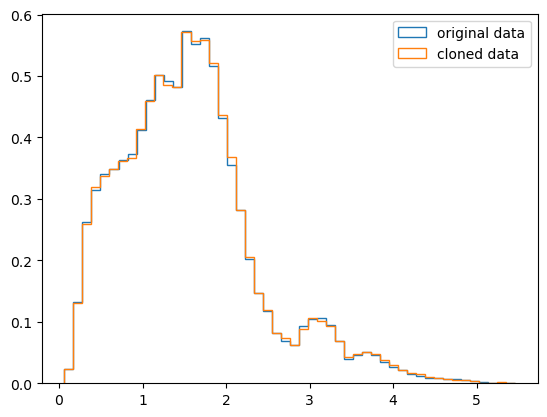

In [6]:
plt.hist(data,bins=50,histtype='step',density=True,label='original data');

# make a histogram object
counts, bins = np.histogram(data, bins=50, density=True)

# Make a scipy.stats random variable object from a histogram
disth = scipy.stats.rv_histogram((counts,bins))

plt.hist(disth.rvs(size=N),bins=50,density=True,histtype='step',label='cloned data');

plt.legend();

## Now some cosmology...

Let's try to assume that quasars are distributed uniformly in comoving volume in the Universe. Seems fair...

We use the cosmological parameters as measured by the Plack satellite, which is a flat $\Lambda$ CDM model



In [7]:
astropy.cosmology.Planck18

FlatLambdaCDM(name='Planck18', H0=<Quantity 67.66 km / (Mpc s)>, Om0=0.30966, Tcmb0=<Quantity 2.7255 K>, Neff=3.046, m_nu=<Quantity [0.  , 0.  , 0.06] eV>, Ob0=0.04897)

In [8]:
z_vals = np.linspace(0,5,100)
comvol = astropy.cosmology.Planck18.differential_comoving_volume(z_vals).value

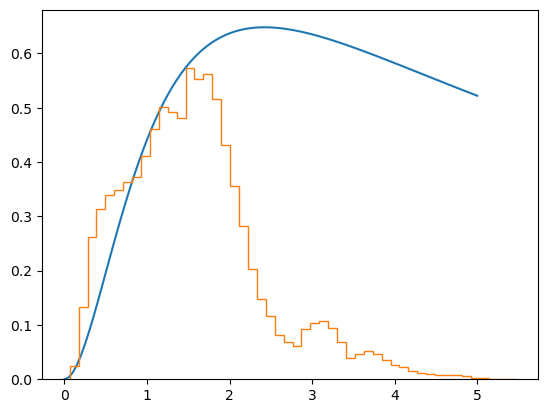

In [9]:
z = np.linspace(0,5,100)
plt.plot(z,comvol/6.5e10) ###   Arbitrary normalization, just matching by eye

plt.hist(data,bins=50,histtype='step',density=True,label='original data');

They are not distributed unifiormly in comoving volume! I mean, they are but only at low redshits.

Surely are all quasars created equally? But do we see them equally?